# k6 + Prometheus + Edge Cache Analysis

Use this notebook as the main visual lab for throughput, latency, and edge cache-lock investigation.

Suggested flow:
- Start the stack in Codespaces.
- Run a baseline load with `bash scripts/run-smoke.sh`.
- For cache-lock probing, run a hot-object burst such as:
  `LOCK_PROBE_RATE=5 LOCK_PROBE_SPIKE=80 bash scripts/run-smoke.sh`
- Re-run the cells below to refresh the charts.


In [1]:
from __future__ import annotations

from datetime import datetime, timedelta, timezone
from pathlib import Path
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

project_root = Path.cwd().resolve().parents[1]
src_dir = project_root / "python" / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from prometheus_tools import instant_query, query_range

PROMETHEUS_URL = os.getenv("PROMETHEUS_URL", "http://localhost:9090")
EDGE_LOG_PATH = project_root / "edge" / "logs" / "edge-access.log"


In [2]:
lookback_minutes = 20
step = "15s"
end = datetime.now(timezone.utc)
start = end - timedelta(minutes=lookback_minutes)

rate_df = query_range(
    "rate(k6_http_reqs_total[1m])",
    start,
    end,
    step=step,
    prometheus_url=PROMETHEUS_URL,
)
latency_df = query_range(
    "k6_http_req_duration_p95",
    start,
    end,
    step=step,
    prometheus_url=PROMETHEUS_URL,
)
up_df = instant_query("up", prometheus_url=PROMETHEUS_URL)

for frame in (rate_df, latency_df):
    if frame.empty:
        continue
    frame["name"] = frame.get("name", pd.Series(index=frame.index)).fillna("unknown")
    frame["scenario"] = frame.get("scenario", pd.Series(index=frame.index)).fillna("unknown")
    frame["traffic"] = frame.get("traffic", pd.Series(index=frame.index)).fillna("unknown")
    frame["status"] = frame.get("status", pd.Series(index=frame.index)).fillna("unknown")

latency_df = latency_df.copy()
if not latency_df.empty:
    latency_df["value_ms"] = latency_df["value"] * 1000.0

print(f"Window: {start.isoformat()} to {end.isoformat()}")
print(f"Prometheus URL: {PROMETHEUS_URL}")
print(f"Edge log: {EDGE_LOG_PATH}")
print(f"Rate samples: {len(rate_df)}")
print(f"Latency samples: {len(latency_df)}")


Window: 2026-03-27T23:11:56.804914+00:00 to 2026-03-27T23:31:56.804914+00:00
Prometheus URL: http://localhost:9090
Edge log: /workspaces/Development/K6_Playground/edge/logs/edge-access.log
Rate samples: 0
Latency samples: 0


## k6 Open vs Closed Models in This Script

Your [smoke.js](/workspaces/Development/K6_Playground/k6/smoke.js) uses both workload models:

- `live_steady` and `vod_steady` use `constant-vus`, which is a **closed model**.
  Closed means a fixed number of VUs loop, wait for responses, then start the next iteration.
  If latency rises, effective throughput usually drops because the same VUs stay busy longer.
- `live_joiners` and `vod_lock_probe` use `ramping-arrival-rate`, which is an **open model**.
  Open means k6 tries to start work at a target arrival rate even if prior requests are still in flight.
  If latency rises, concurrency tends to grow because arrivals keep coming.

Little's Law is the short mental model for the open side:

- `L = lambda * W`
- `L` = average in-flight work
- `lambda` = arrival rate in requests per second
- `W` = average time spent in the system in seconds

That means if the cache-lock probe keeps arrivals high while edge latency jumps, the number of in-flight requests grows too. That is why open-model bursts are useful for exposing queueing and cache-lock behavior.


In [3]:
little_df = pd.merge(
    rate_df[["timestamp", "scenario", "name", "value"]].rename(columns={"value": "req_per_sec"}),
    latency_df[["timestamp", "scenario", "name", "value_ms"]],
    on=["timestamp", "scenario", "name"],
    how="inner",
)

if not little_df.empty:
    little_df["estimated_inflight"] = little_df["req_per_sec"] * (little_df["value_ms"] / 1000.0)
    scenario_little = (
        little_df.groupby(["timestamp", "scenario"], dropna=False)["estimated_inflight"]
        .mean()
        .reset_index()
    )
else:
    scenario_little = pd.DataFrame(columns=["timestamp", "scenario", "estimated_inflight"])

fig, axes = plt.subplots(1, 2, figsize=(20, 7), gridspec_kw={"width_ratios": [1.15, 1]})

if scenario_little.empty:
    for ax in axes:
        ax.text(0.5, 0.5, "No overlapping rate/latency data for Little's Law estimate", ha="center", va="center")
        ax.set_axis_off()
else:
    sns.lineplot(
        data=scenario_little,
        x="timestamp",
        y="estimated_inflight",
        hue="scenario",
        linewidth=3,
        ax=axes[0],
    )
    axes[0].set_title("Estimated In-Flight Requests by Scenario")
    axes[0].set_xlabel("time")
    axes[0].set_ylabel("lambda * W")

    scenario_summary = (
        scenario_little.groupby("scenario", dropna=False)["estimated_inflight"]
        .agg(["mean", "max"])
        .reset_index()
        .melt(id_vars="scenario", var_name="stat", value_name="estimated_inflight")
    )
    sns.barplot(
        data=scenario_summary,
        x="scenario",
        y="estimated_inflight",
        hue="stat",
        ax=axes[1],
    )
    axes[1].set_title("Little's Law Summary by Scenario")
    axes[1].set_xlabel("scenario")
    axes[1].set_ylabel("estimated in-flight requests")
    axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()


KeyError: "['scenario', 'name'] not in index"

/tmp/ipykernel_52841/522120635.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate_summary, x="name", y="value", palette="crest", ax=axes[1])


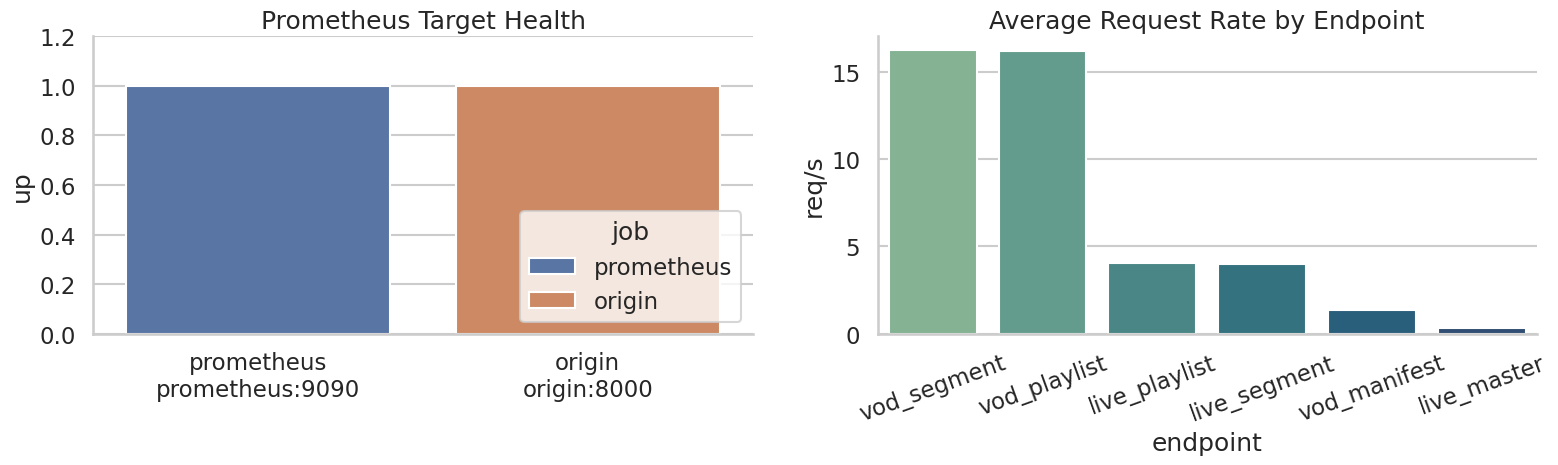

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

health = up_df.copy()
if health.empty:
    axes[0].text(0.5, 0.5, "No scrape targets returned", ha="center", va="center")
    axes[0].set_axis_off()
else:
    health["target"] = health["job"] + "\n" + health["instance"]
    sns.barplot(data=health, x="target", y="value", hue="job", dodge=False, ax=axes[0])
    axes[0].set_title("Prometheus Target Health")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("up")
    axes[0].set_ylim(0, 1.2)
    axes[0].legend(title="job", loc="lower right")

if rate_df.empty:
    axes[1].text(0.5, 0.5, "No request-rate data", ha="center", va="center")
    axes[1].set_axis_off()
else:
    rate_summary = (
        rate_df.groupby("name", dropna=False)["value"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    sns.barplot(data=rate_summary, x="name", y="value", palette="crest", ax=axes[1])
    axes[1].set_title("Average Request Rate by Endpoint")
    axes[1].set_xlabel("endpoint")
    axes[1].set_ylabel("req/s")
    axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()


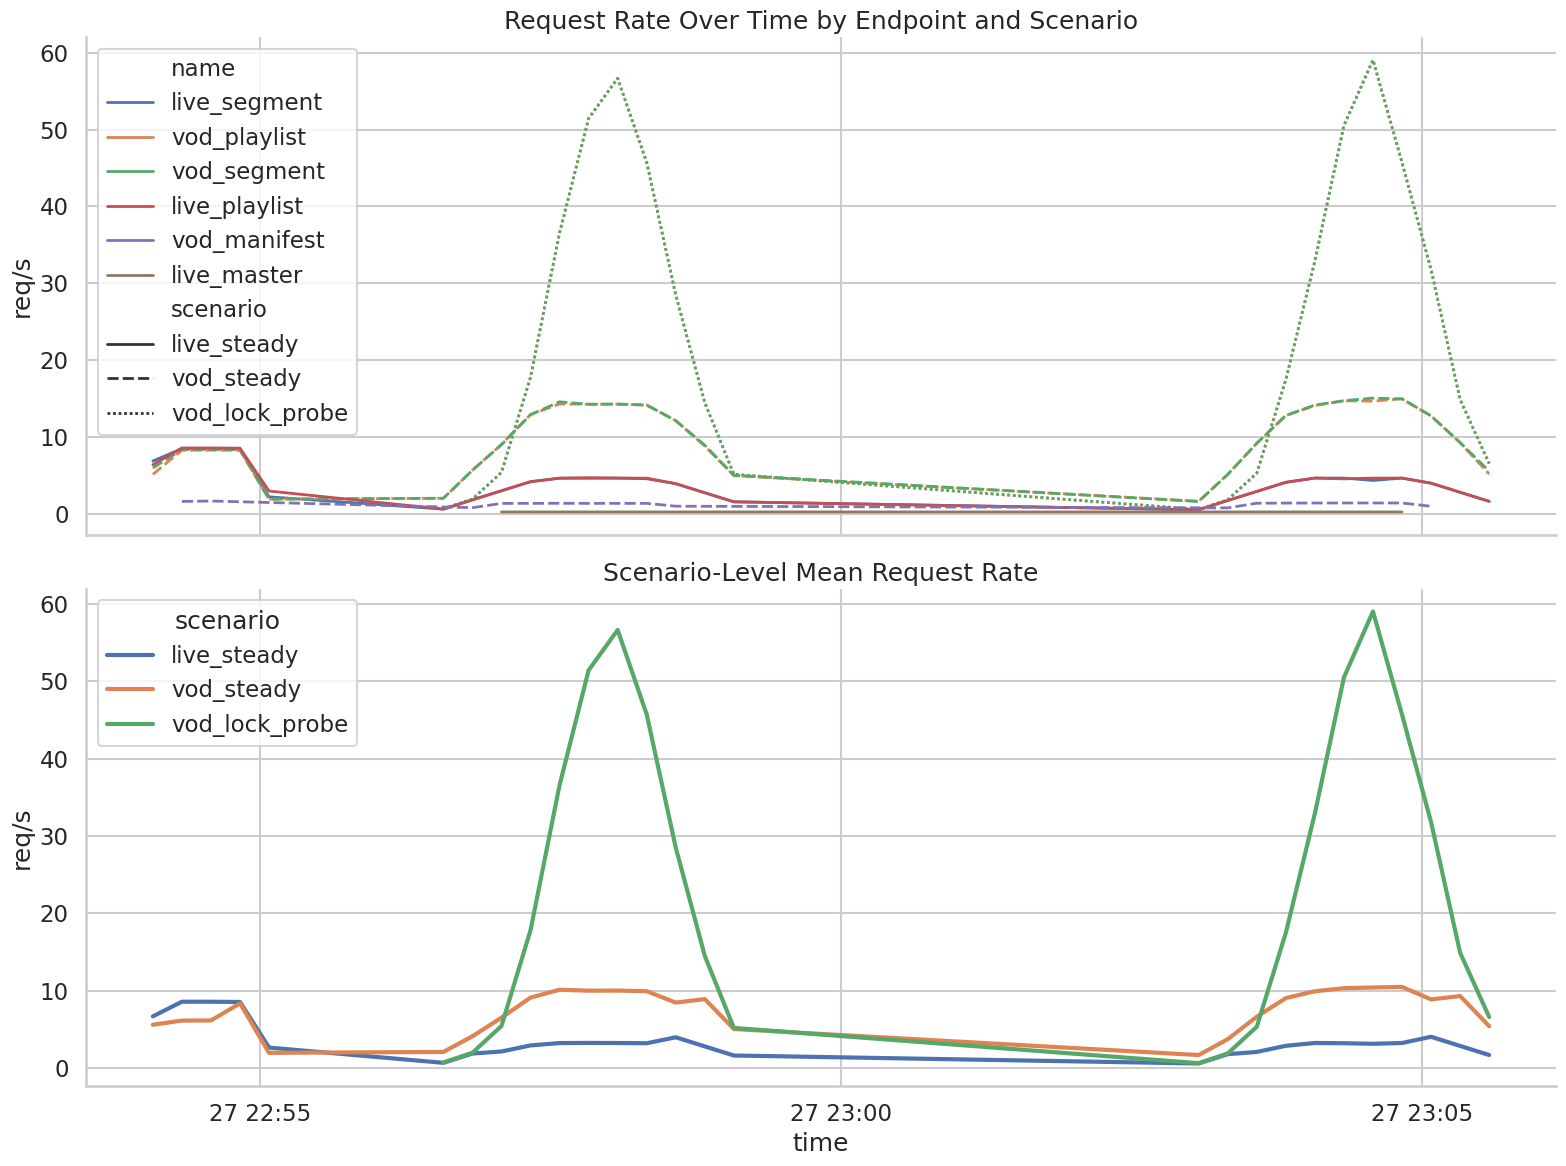

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

if rate_df.empty:
    for ax in axes:
        ax.text(0.5, 0.5, "No request-rate data", ha="center", va="center")
        ax.set_axis_off()
else:
    sns.lineplot(
        data=rate_df.sort_values("timestamp"),
        x="timestamp",
        y="value",
        hue="name",
        style="scenario",
        linewidth=2,
        ax=axes[0],
    )
    axes[0].set_title("Request Rate Over Time by Endpoint and Scenario")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("req/s")

    scenario_rate = (
        rate_df.groupby(["timestamp", "scenario"], dropna=False)["value"]
        .mean()
        .reset_index()
    )
    sns.lineplot(
        data=scenario_rate,
        x="timestamp",
        y="value",
        hue="scenario",
        linewidth=3,
        ax=axes[1],
    )
    axes[1].set_title("Scenario-Level Mean Request Rate")
    axes[1].set_xlabel("time")
    axes[1].set_ylabel("req/s")

plt.tight_layout()


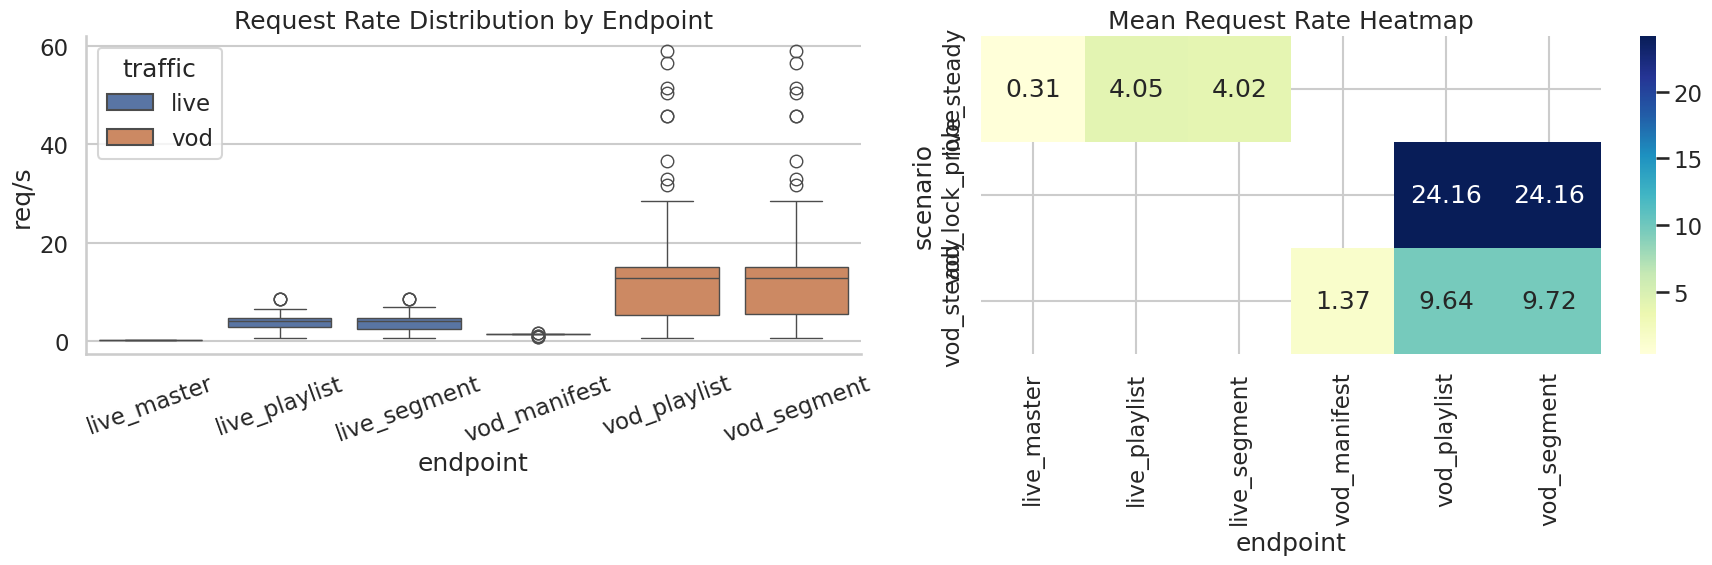

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7), gridspec_kw={"width_ratios": [1.15, 1]})

if rate_df.empty:
    for ax in axes:
        ax.text(0.5, 0.5, "No request-rate data", ha="center", va="center")
        ax.set_axis_off()
else:
    sns.boxplot(data=rate_df, x="name", y="value", hue="traffic", ax=axes[0])
    axes[0].set_title("Request Rate Distribution by Endpoint")
    axes[0].set_xlabel("endpoint")
    axes[0].set_ylabel("req/s")
    axes[0].tick_params(axis="x", rotation=20)

    rate_heatmap = (
        rate_df.pivot_table(
            index="scenario",
            columns="name",
            values="value",
            aggfunc="mean",
        )
        .sort_index()
    )
    sns.heatmap(rate_heatmap, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[1])
    axes[1].set_title("Mean Request Rate Heatmap")
    axes[1].set_xlabel("endpoint")
    axes[1].set_ylabel("scenario")

plt.tight_layout()


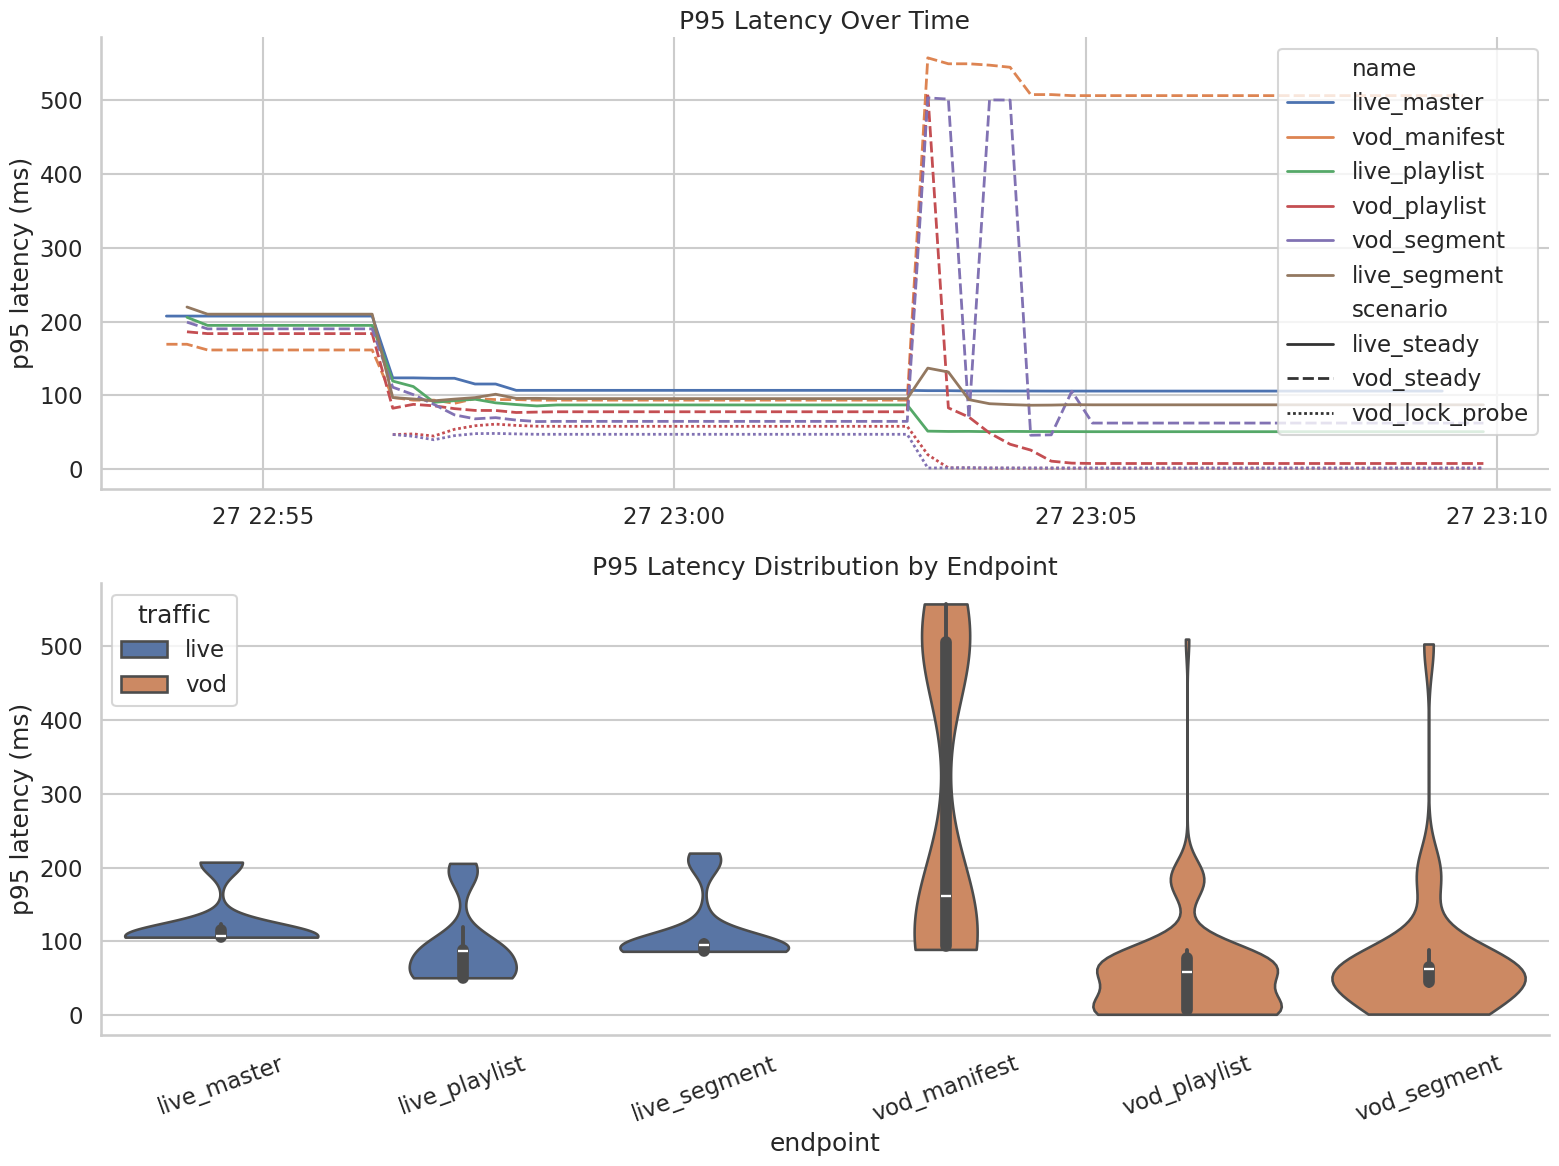

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

if latency_df.empty:
    for ax in axes:
        ax.text(0.5, 0.5, "No latency data", ha="center", va="center")
        ax.set_axis_off()
else:
    sns.lineplot(
        data=latency_df.sort_values("timestamp"),
        x="timestamp",
        y="value_ms",
        hue="name",
        style="scenario",
        linewidth=2,
        ax=axes[0],
    )
    axes[0].set_title("P95 Latency Over Time")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("p95 latency (ms)")

    sns.violinplot(data=latency_df, x="name", y="value_ms", hue="traffic", cut=0, ax=axes[1])
    axes[1].set_title("P95 Latency Distribution by Endpoint")
    axes[1].set_xlabel("endpoint")
    axes[1].set_ylabel("p95 latency (ms)")
    axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()


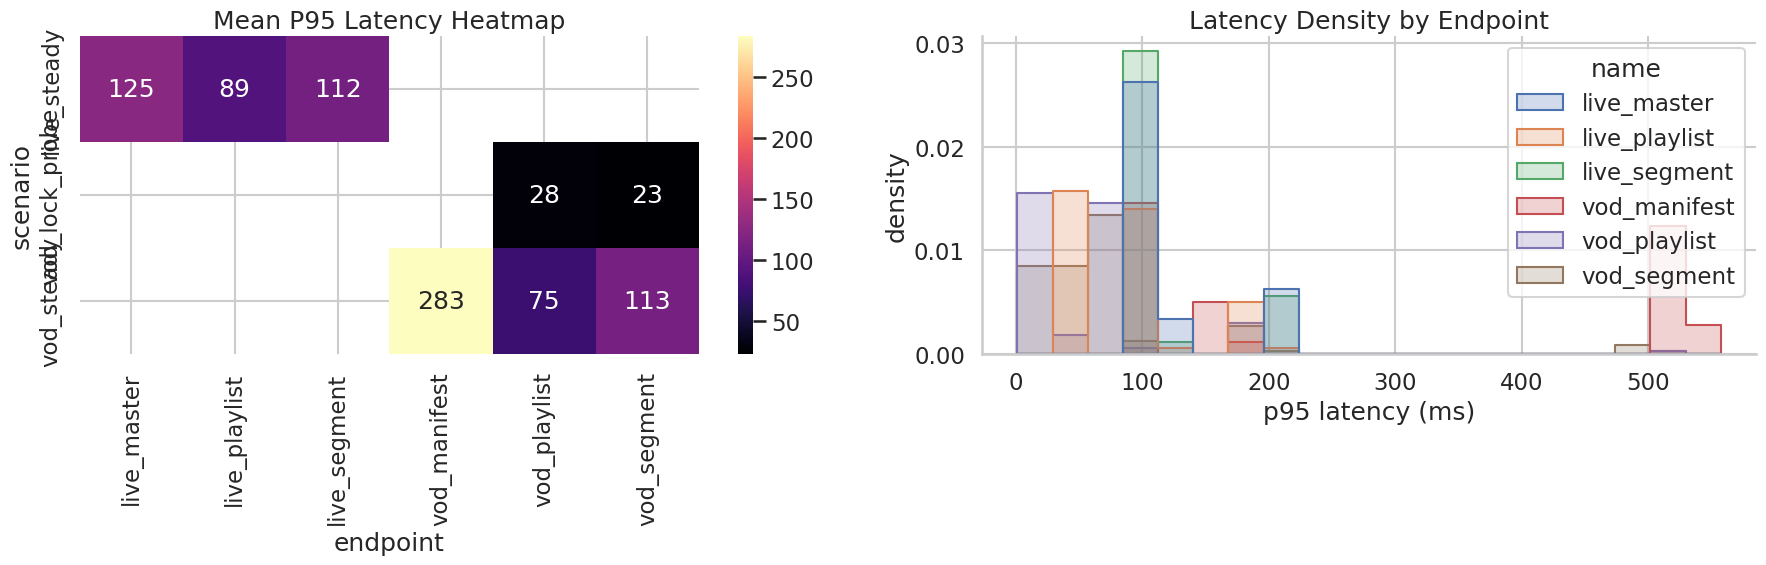

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7), gridspec_kw={"width_ratios": [1.15, 1]})

if latency_df.empty:
    for ax in axes:
        ax.text(0.5, 0.5, "No latency data", ha="center", va="center")
        ax.set_axis_off()
else:
    latency_heatmap = (
        latency_df.pivot_table(
            index="scenario",
            columns="name",
            values="value_ms",
            aggfunc="mean",
        )
        .sort_index()
    )
    sns.heatmap(latency_heatmap, annot=True, fmt=".0f", cmap="magma", ax=axes[0])
    axes[0].set_title("Mean P95 Latency Heatmap")
    axes[0].set_xlabel("endpoint")
    axes[0].set_ylabel("scenario")
    axes[0].tick_params(axis="x", labelrotation=90)
    axes[0].tick_params(axis="y", labelrotation=0, pad=8)
    for label in axes[0].get_xticklabels():
        label.set_ha("right")
        label.set_rotation_mode("anchor")

    sns.histplot(
        data=latency_df,
        x="value_ms",
        hue="name",
        bins=20,
        element="step",
        stat="density",
        common_norm=False,
        ax=axes[1],
    )
    axes[1].set_title("Latency Density by Endpoint")
    axes[1].set_xlabel("p95 latency (ms)")
    axes[1].set_ylabel("density")

fig.subplots_adjust(left=0.12, bottom=0.28, wspace=0.42)
plt.tight_layout()


/tmp/ipykernel_52841/4256603812.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda frame: frame[["req_per_sec", "value_ms"]].corr().iloc[0, 1])


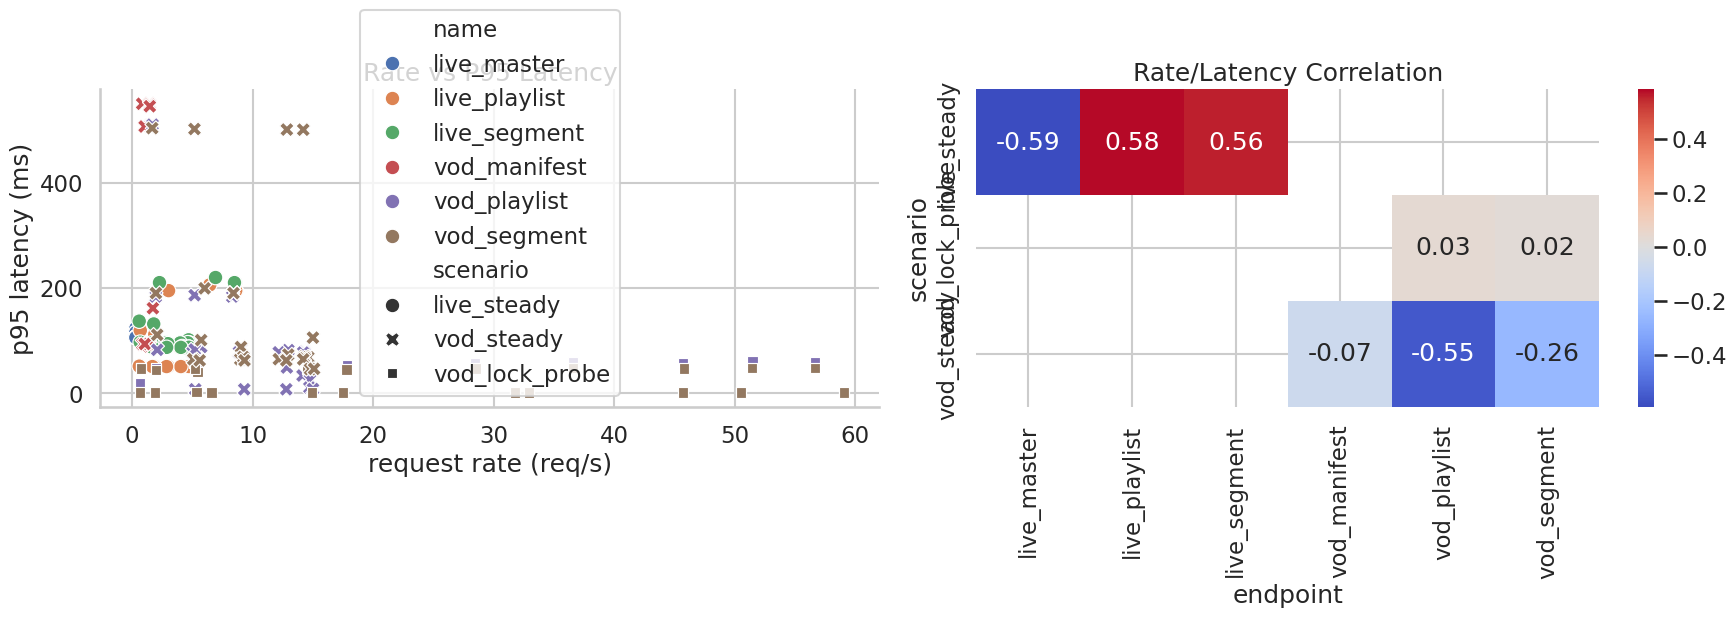

In [ ]:
merge_keys = ["timestamp", "scenario", "name", "traffic", "status"]
merged = pd.merge(
    rate_df[merge_keys + ["value"]].rename(columns={"value": "req_per_sec"}),
    latency_df[merge_keys + ["value_ms"]],
    on=merge_keys,
    how="inner",
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

if merged.empty:
    for ax in axes:
        ax.text(0.5, 0.5, "No overlap between rate and latency samples", ha="center", va="center")
        ax.set_axis_off()
else:
    sns.scatterplot(
        data=merged,
        x="req_per_sec",
        y="value_ms",
        hue="name",
        style="scenario",
        s=110,
        ax=axes[0],
    )
    axes[0].set_title("Rate vs P95 Latency")
    axes[0].set_xlabel("request rate (req/s)")
    axes[0].set_ylabel("p95 latency (ms)")

    corr_view = (
        merged.groupby(["scenario", "name"], dropna=False)
        .apply(lambda frame: frame[["req_per_sec", "value_ms"]].corr().iloc[0, 1])
        .reset_index(name="correlation")
    )
    corr_pivot = corr_view.pivot(index="scenario", columns="name", values="correlation")
    sns.heatmap(corr_pivot, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
    axes[1].set_title("Rate/Latency Correlation")
    axes[1].set_xlabel("endpoint")
    axes[1].set_ylabel("scenario")

plt.tight_layout()


## Edge Cache Lock Investigation

This section reads the NGINX access log directly from `edge/logs/access.log`.

What to look for:
- A burst of `MISS` requests for the same `cache_key` means the edge is cold.
- A transition from `MISS` to mostly `HIT` means the cache has warmed.
- If request time spikes during a hot-key burst while origin fetches stay low, that is consistent with waiting behind `proxy_cache_lock`.
- The `vod_lock_probe` scenario is designed to make this visible by hammering the same VOD playlist and segment.


In [ ]:
def load_edge_log(path: Path, since: datetime) -> pd.DataFrame:
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame()

    rows = []
    for line in path.read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except json.JSONDecodeError:
            continue

    if not rows:
        return pd.DataFrame()

    edge_df = pd.DataFrame(rows)
    edge_df["time"] = pd.to_datetime(edge_df["time"], utc=True, errors="coerce")
    edge_df = edge_df.dropna(subset=["time"]).copy()
    edge_df = edge_df[edge_df["time"] >= since].copy()
    if edge_df.empty:
        return edge_df

    edge_df["request_time"] = pd.to_numeric(edge_df["request_time"], errors="coerce")
    edge_df["upstream_response_time"] = pd.to_numeric(edge_df["upstream_response_time"], errors="coerce")
    edge_df["status"] = pd.to_numeric(edge_df["status"], errors="coerce")
    edge_df["upstream_cache_status"] = edge_df["upstream_cache_status"].replace({"": "NONE"}).fillna("NONE")
    edge_df["endpoint"] = edge_df["uri"].str.extract(r"/(master\.m3u8|live\.m3u8|playlist\.m3u8|seg_\d+\.ts)$", expand=False)
    edge_df["endpoint"] = edge_df["endpoint"].fillna(edge_df["uri"])
    edge_df["cache_wait_ms"] = ((edge_df["request_time"] - edge_df["upstream_response_time"].fillna(0)) * 1000).clip(lower=0)
    return edge_df.sort_values("time")


edge_df = load_edge_log(EDGE_LOG_PATH, start)
print(f"Edge log rows in window: {len(edge_df)}")
if not edge_df.empty:
    display(edge_df[["time", "uri", "status", "upstream_cache_status", "request_time", "upstream_response_time", "cache_wait_ms"]].tail(10))


Edge log rows in window: 12848


,time,uri,status,upstream_cache_status,request_time,upstream_response_time,cache_wait_ms
12778,2026-03-27 23:04:53+00:00,/vod/movie1/playlist.m3u8,200,HIT,0.0,NaN,0.0
12775,2026-03-27 23:04:53+00:00,/vod/movie1/seg_0059.ts,200,HIT,0.0,NaN,0.0
12846,2026-03-27 23:04:54+00:00,/vod/movie1/playlist.m3u8,200,HIT,0.0,NaN,0.0
12840,2026-03-27 23:04:54+00:00,/vod/movie1/playlist.m3u8,200,HIT,0.0,NaN,0.0
12841,2026-03-27 23:04:54+00:00,/vod/movie1/seg_0007.ts,200,HIT,0.0,NaN,0.0
12842,2026-03-27 23:04:54+00:00,/vod/movie1/playlist.m3u8,200,HIT,0.0,NaN,0.0
12843,2026-03-27 23:04:54+00:00,/vod/movie1/seg_0007.ts,200,HIT,0.0,NaN,0.0
12844,2026-03-27 23:04:54+00:00,/vod/movie1/playlist.m3u8,200,HIT,0.0,NaN,0.0
12845,2026-03-27 23:04:54+00:00,/vod/movie1/seg_0007.ts,200,HIT,0.0,NaN,0.0
12847,2026-03-27 23:04:54+00:00,/vod/movie1/seg_0007.ts,200,HIT,0.0,NaN,0.0


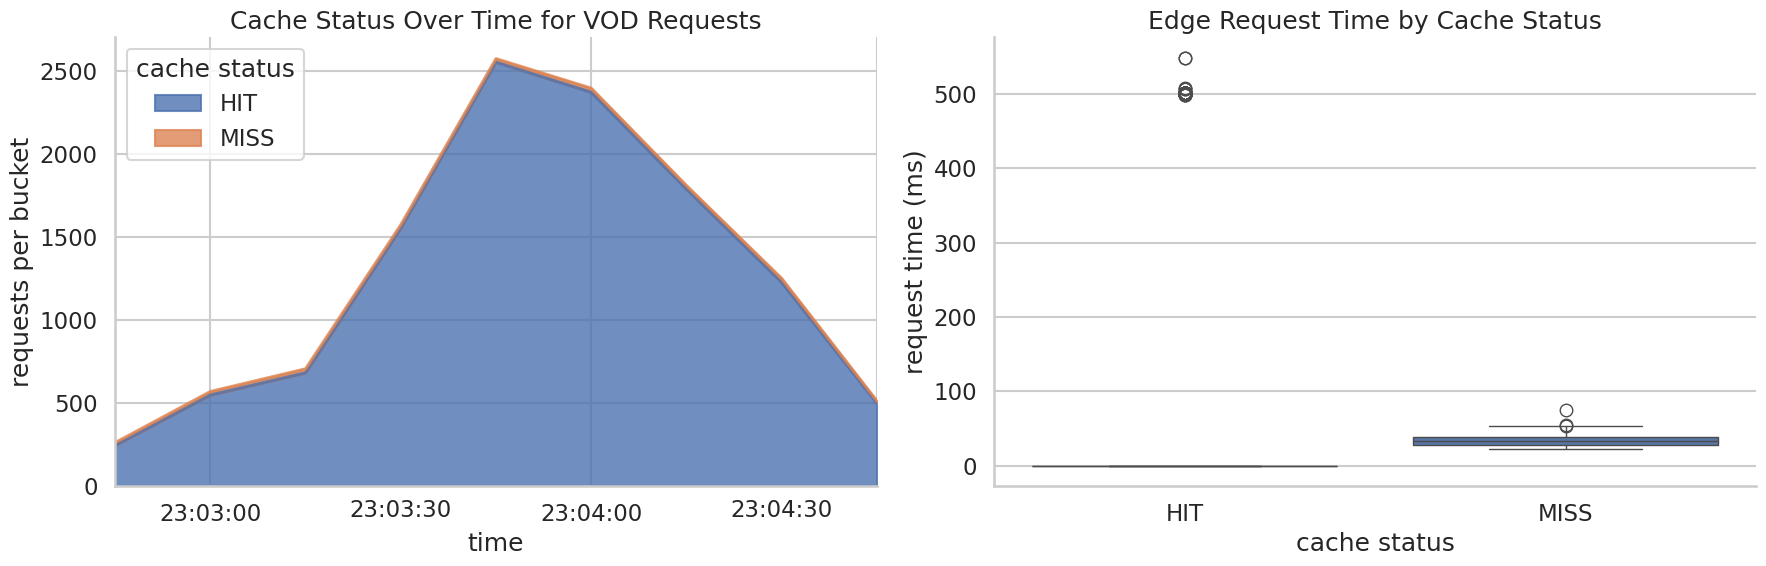

In [ ]:
cacheable_df = edge_df[edge_df["traffic_class"] == "vod"].copy() if not edge_df.empty else pd.DataFrame()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

if cacheable_df.empty:
    for ax in axes:
        ax.text(0.5, 0.5, "No VOD edge cache log data yet", ha="center", va="center")
        ax.set_axis_off()
else:
    status_counts = (
        cacheable_df.set_index("time")
        .groupby([pd.Grouper(freq="15s"), "upstream_cache_status"])
        .size()
        .unstack(fill_value=0)
    )
    status_counts.plot.area(ax=axes[0], alpha=0.8)
    axes[0].set_title("Cache Status Over Time for VOD Requests")
    axes[0].set_xlabel("time")
    axes[0].set_ylabel("requests per bucket")
    axes[0].legend(title="cache status", loc="upper left")

    latency_by_status = cacheable_df.copy()
    latency_by_status["request_time_ms"] = latency_by_status["request_time"] * 1000.0
    sns.boxplot(
        data=latency_by_status,
        x="upstream_cache_status",
        y="request_time_ms",
        order=sorted(latency_by_status["upstream_cache_status"].unique()),
        ax=axes[1],
    )
    axes[1].set_title("Edge Request Time by Cache Status")
    axes[1].set_xlabel("cache status")
    axes[1].set_ylabel("request time (ms)")

plt.tight_layout()


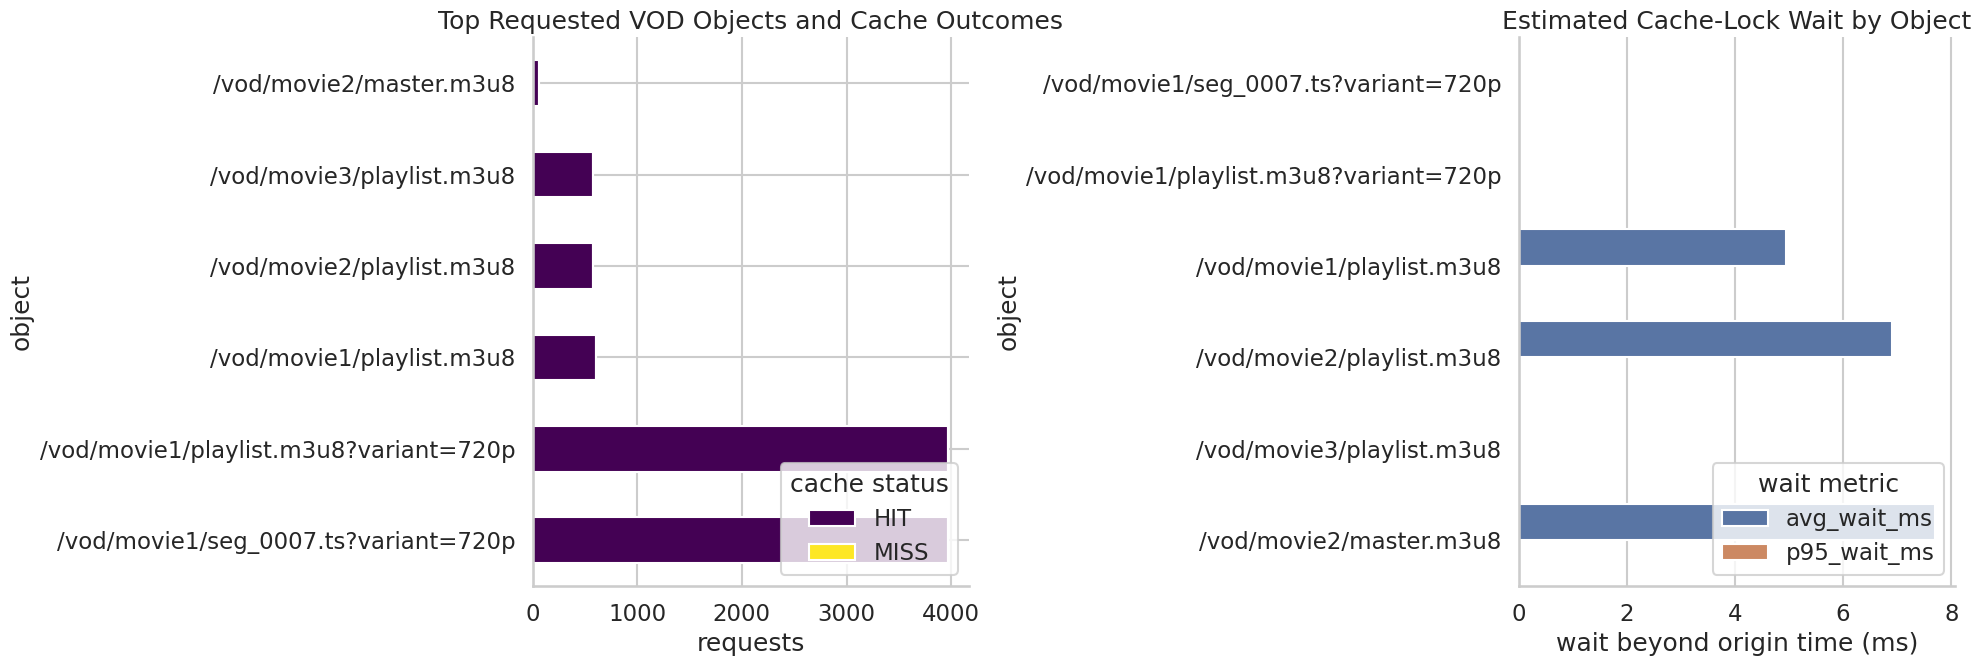

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

if cacheable_df.empty:
    for ax in axes:
        ax.text(0.5, 0.5, "No VOD edge cache log data yet", ha="center", va="center")
        ax.set_axis_off()
else:
    plot_df = cacheable_df.copy()
    plot_df["request_target"] = plot_df["uri"].fillna("")
    plot_df["variant"] = (
        plot_df["args"]
        .fillna("")
        .str.extract(r"(?:^|&)variant=([^&]+)", expand=False)
        .fillna("")
    )
    has_variant = plot_df["variant"].ne("")
    plot_df.loc[has_variant, "request_target"] = (
        plot_df.loc[has_variant, "uri"].fillna("")
        + "?variant="
        + plot_df.loc[has_variant, "variant"]
    )

    top_targets = plot_df["request_target"].value_counts().head(6).index
    top_df = plot_df[plot_df["request_target"].isin(top_targets)].copy()

    status_mix = (
        top_df.groupby(["request_target", "upstream_cache_status"], dropna=False)
        .size()
        .unstack(fill_value=0)
        .loc[top_targets]
    )
    status_mix.plot(kind="barh", stacked=True, ax=axes[0], colormap="viridis")
    axes[0].set_title("Top Requested VOD Objects and Cache Outcomes")
    axes[0].set_xlabel("requests")
    axes[0].set_ylabel("object")
    axes[0].legend(title="cache status", loc="lower right")

    wait_summary = (
        top_df.groupby("request_target", dropna=False)
        .agg(
            avg_wait_ms=("cache_wait_ms", "mean"),
            p95_wait_ms=("cache_wait_ms", lambda s: s.quantile(0.95)),
            avg_request_ms=("request_time", lambda s: s.mean() * 1000.0),
        )
        .loc[top_targets]
        .reset_index()
    )
    wait_long = wait_summary.melt(
        id_vars="request_target",
        value_vars=["avg_wait_ms", "p95_wait_ms"],
        var_name="metric",
        value_name="wait_ms",
    )
    sns.barplot(
        data=wait_long,
        y="request_target",
        x="wait_ms",
        hue="metric",
        ax=axes[1],
    )
    axes[1].set_title("Estimated Cache-Lock Wait by Object")
    axes[1].set_xlabel("wait beyond origin time (ms)")
    axes[1].set_ylabel("object")
    axes[1].legend(title="wait metric", loc="lower right")

plt.tight_layout()
